## Load the dataset

In [75]:
from pathlib import Path
from sklearn.model_selection import train_test_split
import kagglehub
import pandas as pd
import seaborn as sns
import numpy as np
from nltk.corpus import stopwords
from torch.utils.data import TensorDataset, DataLoader
import nltk
nltk.download('all')
# Download latest version
file_name = 'IMDB Dataset.csv'
path = Path.cwd().resolve()
IMDB_DATA = path / "data" / file_name
df = pd.read_csv(IMDB_DATA)
df.head()

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\kofia\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\kofia\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\kofia\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\kofia\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\kofia\AppData\Roaming\nltk_data...
[

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [76]:
import torch


is_cuda = torch.cuda.is_available()

if is_cuda:
    device = torch.device("cuda")
    print("GPU is available")
else:
    device = torch.device('cpu')
    print("GPU not available, CPU used")

GPU is available


## Exploratory Data Analysis

Train data shape: (37500,)
Test data shape: (12500,)


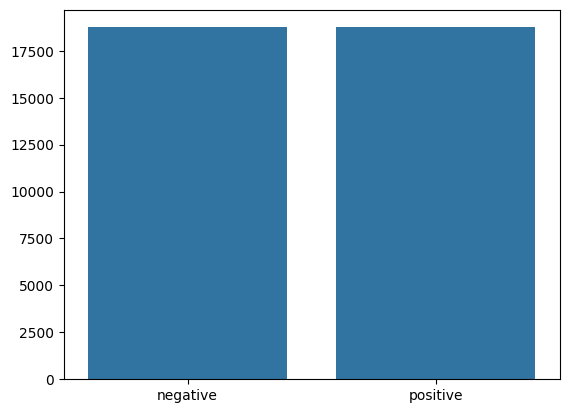

In [77]:
from matplotlib import pyplot as plt


X = df['review'].to_numpy()
y = df['sentiment'].to_numpy()

# X, y = df['review'].values,df['sentiment'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)
print(f'Train data shape: {X_train.shape}')
print(f'Test data shape: {X_test.shape}')

dd = pd.Series(y_train).value_counts()
sns.barplot(x=np.array(['negative', 'positive']), y=dd.values)
plt.show()

## Text Preprocessing

In [78]:
from collections import Counter
import re


def preprocess_string(s):
    #remove all none-word characters (all except numbers and letters)
    s = re.sub(r"[^\w\s]", '', s)
    # Replace all runs of whitespaces with no space
    s = re.sub(r"\s+", '', s)
    #replace digits with no space
    s = re.sub(r"/d", '', s)
    return s


def tokenize(X_train, y_train, x_val, y_val):
    word_list = []
    
    stop_words = set(stopwords.words('english'))
    for sent in X_train:
        for word in sent.lower().split():
            word = preprocess_string(word)
            if word not in stop_words and word != '':
                word_list.append(word)
                
    corpus = Counter(word_list)
    #sorting based on most common words
    corpus_ = sorted(corpus, key=corpus.get, reverse=True)[:1000]
    onehot_dict = {w:i+1 for i, w in enumerate(corpus_)}
    # print(onehot_dict)
    final_list_train, final_list_test = [], []
    for sent in X_train:
        final_list_train.append([onehot_dict[preprocess_string(word)] for word in sent.lower().split()
                                 if preprocess_string(word) in onehot_dict.keys()])
    for sent in x_val:
        final_list_test.append([onehot_dict[preprocess_string(word)] for word in sent.lower().split()
                                if preprocess_string(word) in onehot_dict.keys()])
        
    encoded_train = [1 if label =='positive' else 0 for label in y_train]
    encoded_test = [1 if label =='positive' else 0 for label in y_val]
    return np.array(final_list_train, dtype=object), np.array(encoded_train), np.array(final_list_test, dtype=object), np.array(encoded_test), onehot_dict


X_train, y_train, X_test, y_test, vocab = tokenize(X_train, y_train, X_test, y_test)

<Axes: >

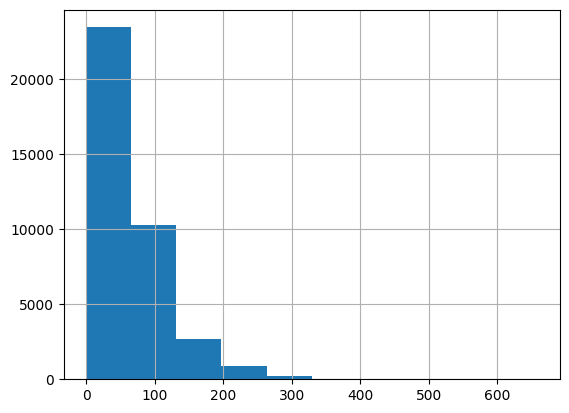

In [79]:
rev_len = [len(i) for i in X_train]
pd.Series(rev_len).hist()

## Preparing the data for the model

In [80]:
def padding_(sentences, seq_len):
    features = np.zeros((len(sentences), seq_len), dtype=int)
    for ii, review in enumerate(sentences):
        if len(review) != 0:
            features[ii, -len(review):] = np.array(review)[:seq_len]
    return features

X_train_pad = padding_(X_train, 500)
X_test_pad = padding_(X_test, 500)

In [81]:
#create tensor datasets
train_data = TensorDataset(torch.from_numpy(X_train_pad), torch.from_numpy(y_train))
valid_data = TensorDataset(torch.from_numpy(X_test_pad), torch.from_numpy(y_test))

batch_size = 50

train_loader = DataLoader(train_data, shuffle=True, batch_size=batch_size)
valid_loader = DataLoader(valid_data, shuffle=True, batch_size=batch_size)

dataiter = iter(train_loader)
sample_x, sample_y = next(dataiter)

print('Sample input size: ', sample_x.size()) #batch_size, seq_length
print('Sample input: \n', sample_x)
print('Sample output: \n', sample_y)

Sample input size:  torch.Size([50, 500])
Sample input: 
 tensor([[  0,   0,   0,  ..., 403, 282, 164],
        [  0,   0,   0,  ..., 393,  26, 232],
        [  0,   0,   0,  ..., 119, 394,  39],
        ...,
        [  0,   0,   0,  ..., 622,   1, 978],
        [  0,   0,   0,  ...,  22, 356, 295],
        [  0,   0,   0,  ..., 990,  23, 869]])
Sample output: 
 tensor([1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
        0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0,
        0, 0])
